In [2]:
import pandas as pd
import numpy as np
import os
import json
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(" Libraries imported successfully!")

c:\Users\prasa\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Libraries imported successfully!


In [3]:
DATA_PATH = '../backend/data/AQ of adoloscents - Sheet.csv'

df = pd.read_csv(DATA_PATH)

if 'Q1' not in df.columns:
    question_cols = df.columns[0:9]
    rename_map = {col: f'Q{i+1}' for i, col in enumerate(question_cols)}
    df = df.rename(columns=rename_map)

# Engineer Target_Category
if 'Target_Category' not in df.columns:
    def categorize_aq(score):
        if score < 2.5: return 0      # Low
        elif score < 3.5: return 1    # Medium
        else: return 2                # High
    df['Target_Category'] = df['AQ'].apply(categorize_aq)

features = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10']
X = df[features]
y = df['Target_Category']

print(f"Data Loaded. Shape: {df.shape}")
df[features + ['Target_Category']].head()

Data Loaded. Shape: (114, 16)


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Target_Category
0,4,5,4,4,5,4,3,4,5,4,2
1,4,4,3,4,4,4,4,4,4,5,2
2,5,5,5,5,3,3,3,2,5,3,2
3,5,5,4,5,5,5,5,5,5,4,2
4,4,4,3,5,4,4,5,4,4,3,2


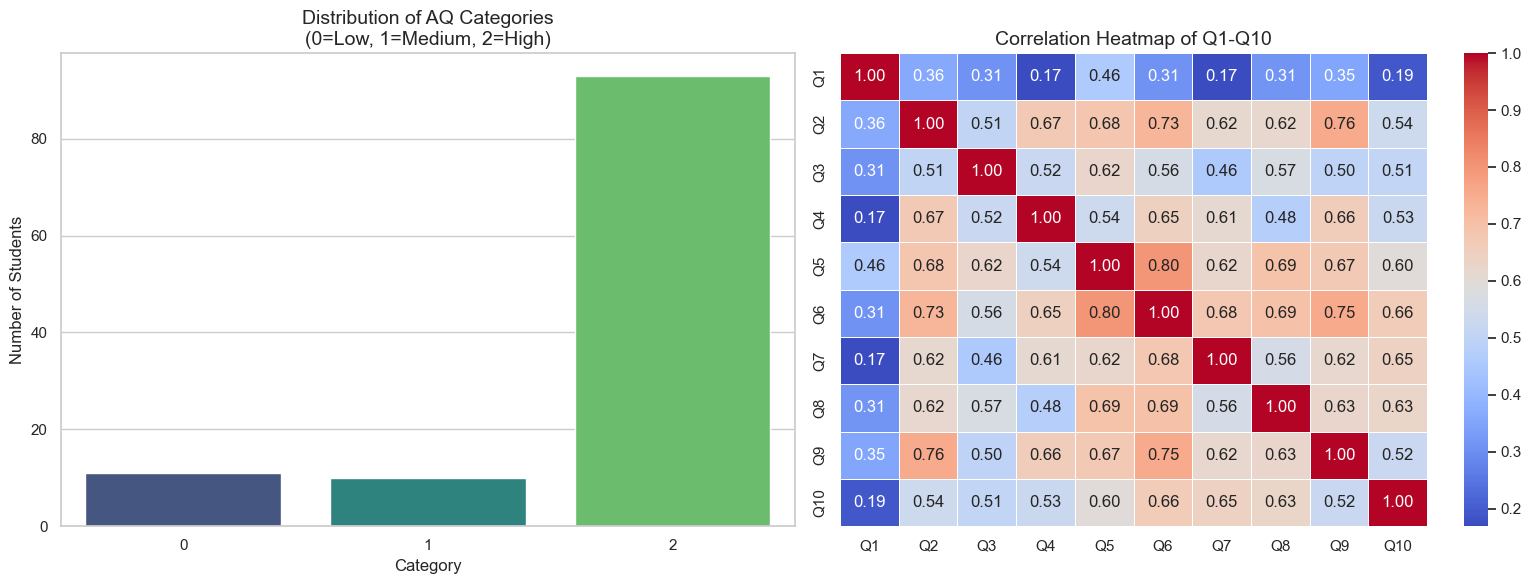

In [4]:
# Cell 3: EDA - Understanding the Data Relationships

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distribution of Target Categories
sns.countplot(data=df, x='Target_Category', palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of AQ Categories\n(0=Low, 1=Medium, 2=High)', fontsize=14)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Students')

# Plot 2: Correlation Heatmap of Questions
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1])
axes[1].set_title('Correlation Heatmap of Q1-Q10', fontsize=14)

plt.tight_layout()
plt.show()

In [5]:
# Cell 4: Train-Test Split and Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_all = scaler.transform(X)

print("Data Split and Scaled!")
print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Testing set: {X_test_scaled.shape[0]} samples")

Data Split and Scaled!
Training set: 91 samples
Testing set: 23 samples


In [6]:
# Cell 5: Train Decision Tree Model and Calculate Metrics
dt_model = DecisionTreeClassifier(
    criterion='gini',       # Split quality measure: 'gini'
    max_depth=5,            # Limit depth to prevent overfitting
    min_samples_split=5,    # Min samples required to split an internal node
    min_samples_leaf=2,     # Min samples required at a leaf node
    random_state=42,
    class_weight='balanced'
)
dt_model.fit(X_train_scaled, y_train)

y_pred = dt_model.predict(X_test_scaled)
y_proba = dt_model.predict_proba(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

try:
    auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
except ValueError:
    auc_score = 0.0

cv_results = cross_validate(dt_model, X_scaled_all, y, cv=5, scoring=['accuracy'])
cv_mean = cv_results['test_accuracy'].mean()
cv_std = cv_results['test_accuracy'].std()

print(f" Accuracy : {acc:.4f}")
print(f" F1 Score : {f1:.4f}")
print(f" AUC-ROC  : {auc_score:.4f}")
print(f" CV Mean  : {cv_mean:.4f} (± {cv_std:.4f})")
print(f" Tree Depth: {dt_model.get_depth()}")
print(f" No. of Leaves: {dt_model.get_n_leaves()}")

 Accuracy : 0.7826
 F1 Score : 0.8265
 AUC-ROC  : 0.9200
 CV Mean  : 0.8079 (± 0.0842)
 Tree Depth: 5
 No. of Leaves: 10


[[ 2  0  0]
 [ 0  2  0]
 [ 0  5 14]]
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         2
      Medium       0.29      1.00      0.44         2
        High       1.00      0.74      0.85        19

    accuracy                           0.78        23
   macro avg       0.76      0.91      0.76        23
weighted avg       0.94      0.78      0.83        23



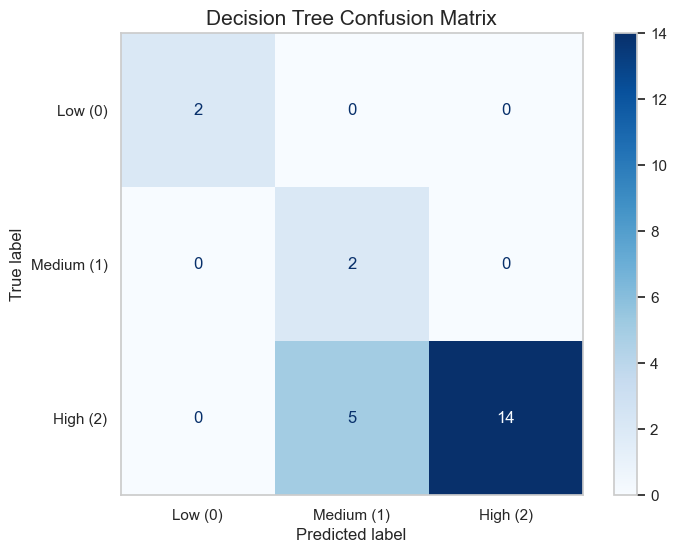

In [7]:

# Cell 6: Confusion Matrix
from sklearn.metrics import classification_report

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low (0)', 'Medium (1)', 'High (2)']
)
print(cm)
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))


fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Decision Tree Confusion Matrix', fontsize=15)
plt.grid(False)
plt.show()

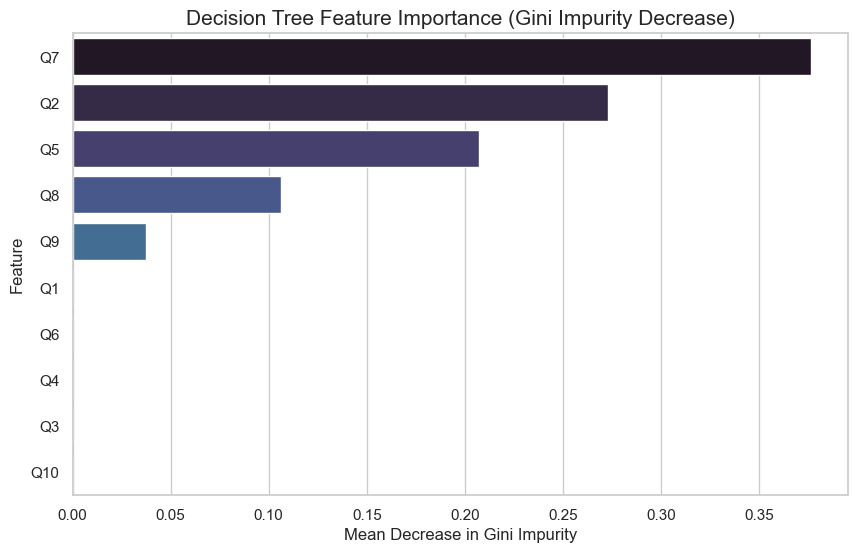

Feature  Importance
     Q7    0.376383
     Q2    0.272998
     Q5    0.207079
     Q8    0.106280
     Q9    0.037260
     Q1    0.000000
     Q6    0.000000
     Q4    0.000000
     Q3    0.000000
    Q10    0.000000


In [8]:
# Cell 7: Feature Importance (Native - Gini Impurity Decrease)
# Decision Tree provides built-in feature_importances_ based on
# total reduction of Gini impurity brought by each feature.
feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='mako')
plt.title('Decision Tree Feature Importance (Gini Impurity Decrease)', fontsize=15)
plt.xlabel('Mean Decrease in Gini Impurity')
plt.show()

print(feat_imp_df.to_string(index=False))

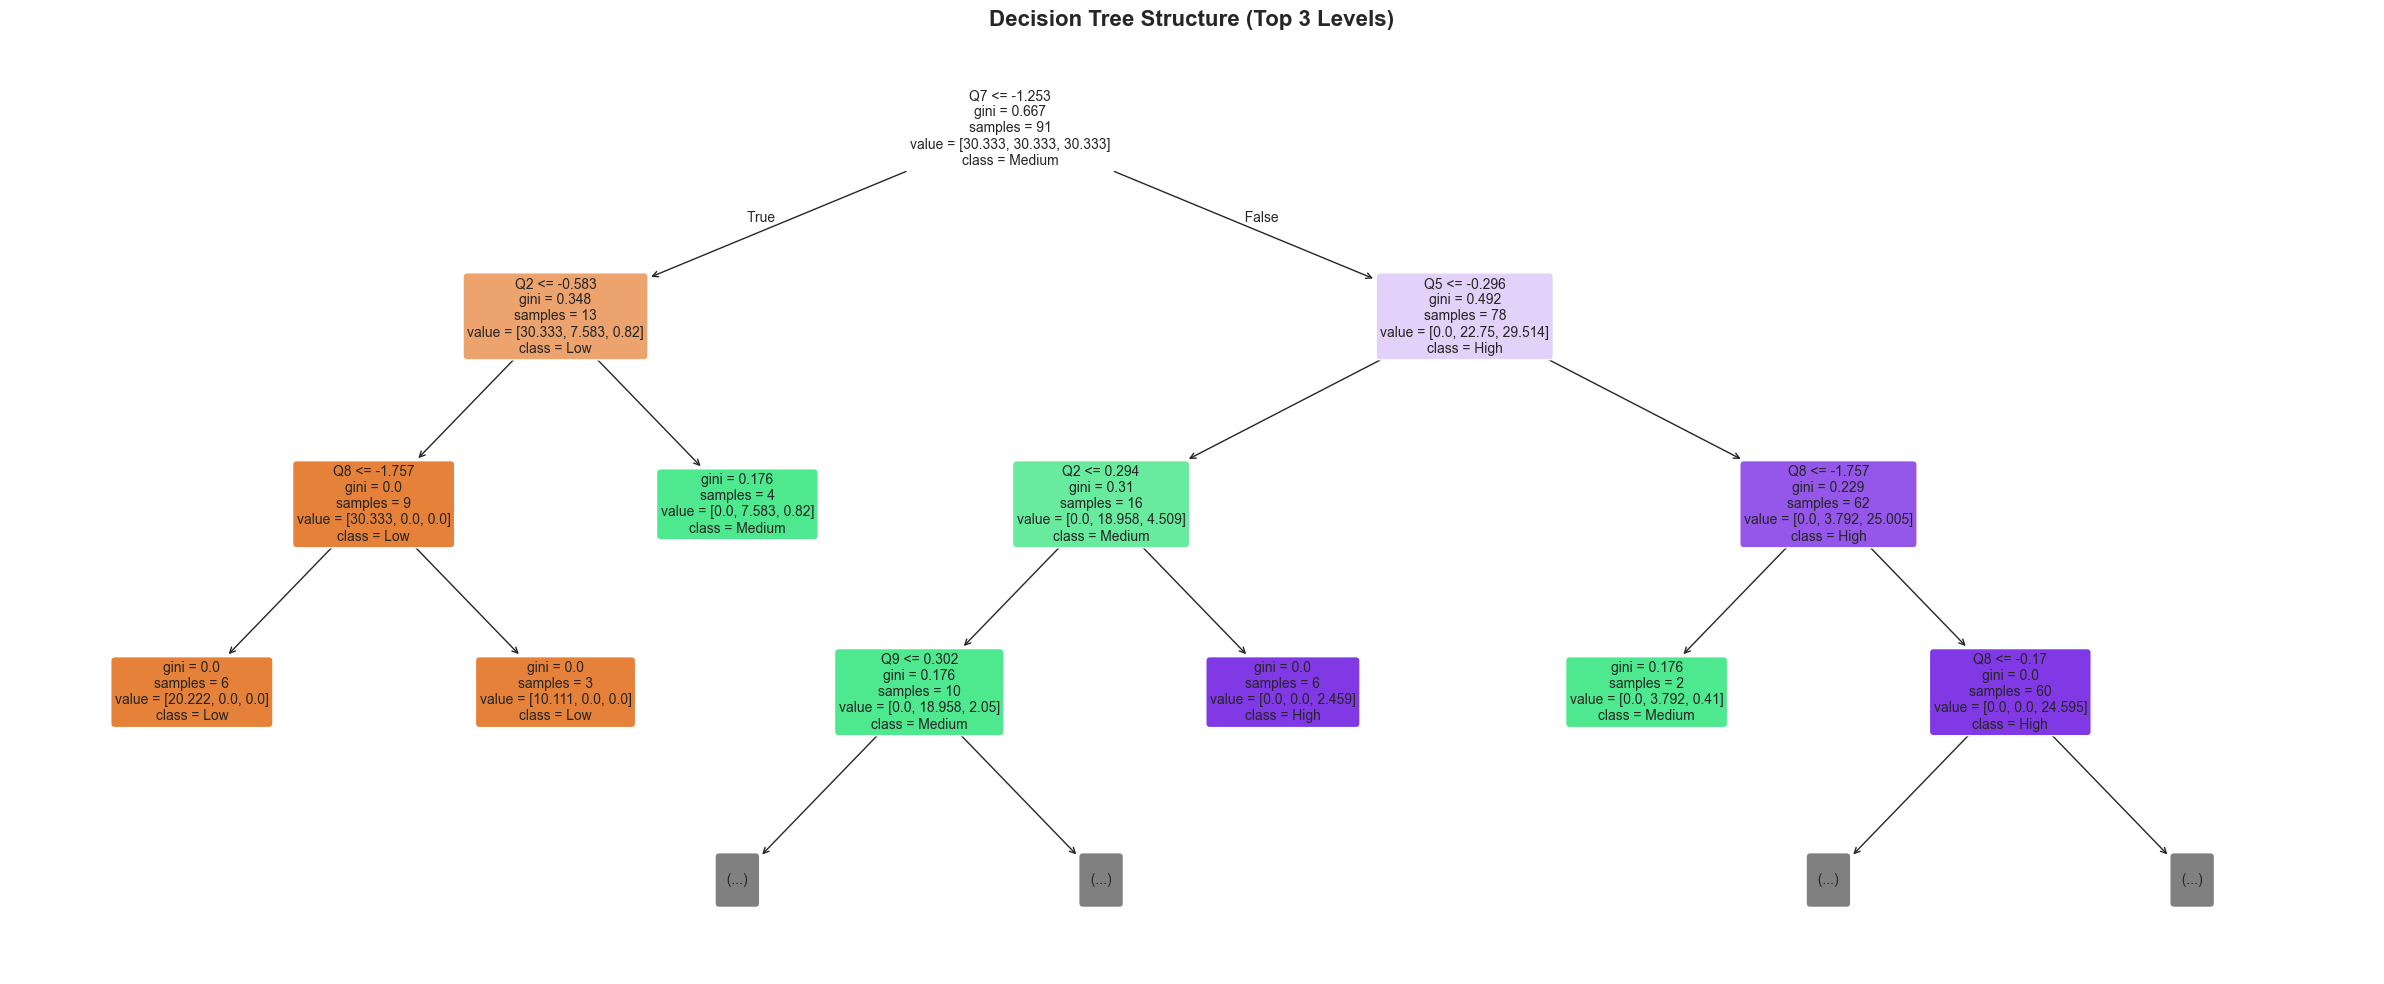

In [9]:
# Cell 8: Decision Tree Visualization
# Visual plot of the trained tree structure (limited to depth=3 for readability)
plt.figure(figsize=(24, 10))
plot_tree(
    dt_model,
    feature_names=features,
    class_names=['Low', 'Medium', 'High'],
    filled=True,
    rounded=True,
    max_depth=3,          # Show top 3 levels for clarity
    fontsize=10,
    impurity=True,
    proportion=False
)
plt.title('Decision Tree Structure (Top 3 Levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

SHAP Summary Plot (Global Impact)


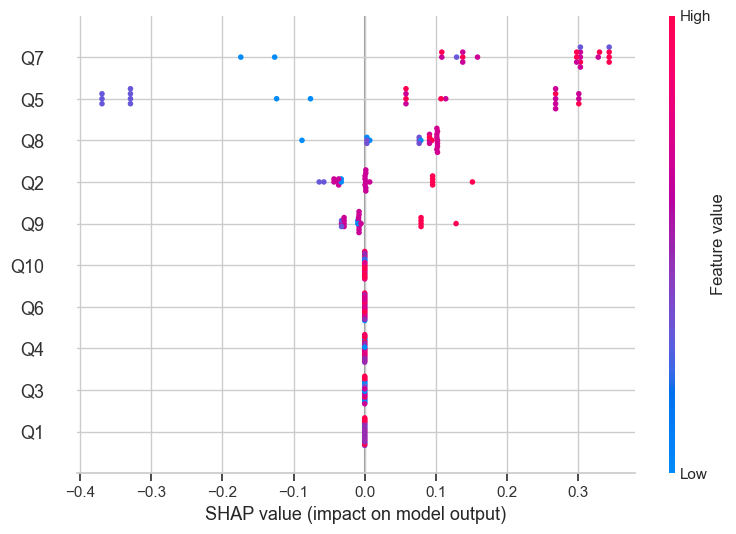

In [10]:
# Cell 9: SHAP Values (TreeExplainer — native support for Decision Trees)
explainer = shap.TreeExplainer(dt_model)
shap_vals = explainer.shap_values(X_test_scaled)

print("SHAP Summary Plot (Global Impact)")

if isinstance(shap_vals, list):
    target_idx = len(shap_vals) - 1
    plot_data = shap_vals[target_idx]
else:
    if len(shap_vals.shape) == 3:
        plot_data = shap_vals[:, :, -1]
    else:
        plot_data = shap_vals

shap.summary_plot(plot_data, X_test_scaled, feature_names=features)

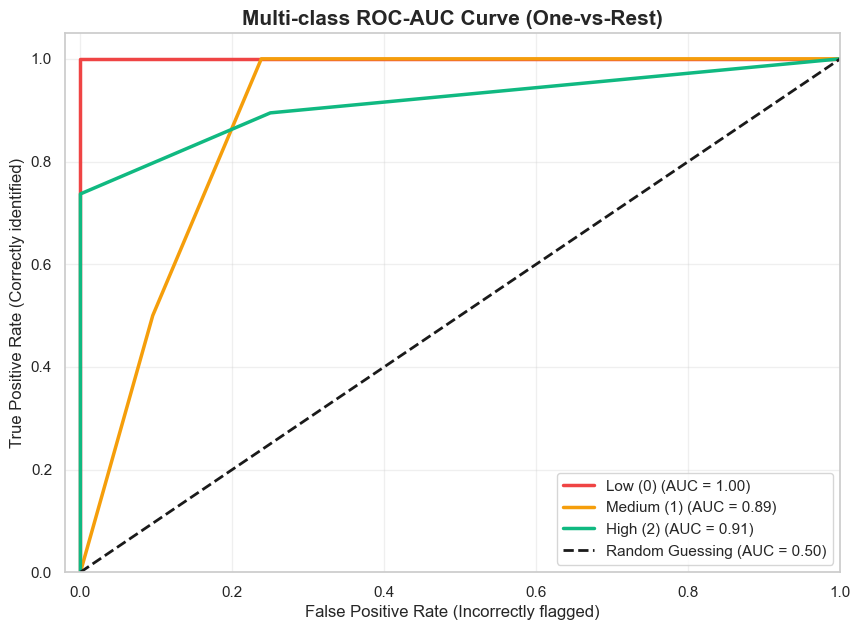

In [11]:
# Cell 10: ROC-AUC Curve (Multi-Class)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc_dict = dict()

class_names = ['Low (0)', 'Medium (1)', 'High (2)']
colors = ['#ef4444', '#f59e0b', '#10b981']

plt.figure(figsize=(10, 7))

y_proba = dt_model.predict_proba(X_test_scaled)

for i in range(n_classes):
    if i in dt_model.classes_ and sum(y_test_bin[:, i]) > 0:
        prob_col_idx = list(dt_model.classes_).index(i)
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, prob_col_idx])
        roc_auc_dict[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2.5,
                 label=f'{class_names[i]} (AUC = {roc_auc_dict[i]:.2f})')
    else:
        print(f"Skipping '{class_names[i]}' - Class not present in predictions or test set.")

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing (AUC = 0.50)')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Incorrectly flagged)', fontsize=12)
plt.ylabel('True Positive Rate (Correctly identified)', fontsize=12)
plt.title('Multi-class ROC-AUC Curve (One-vs-Rest)', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

In [12]:
# Cell 11: Export Data
MODELS_DIR = '../backend/ml_models/decision_tree'
os.makedirs(MODELS_DIR, exist_ok=True)

# 1. Export core ML components
joblib.dump(dt_model, os.path.join(MODELS_DIR, 'decision_tree_model.pkl'))
joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler.pkl'))
joblib.dump(X_train, os.path.join(MODELS_DIR, 'X_train.pkl'))

# 2. Export the SHAP explainer for the FastAPI backend
joblib.dump(explainer, os.path.join(MODELS_DIR, 'shap_explainer.pkl'))

# Compute global SHAP importance across all classes
if isinstance(shap_vals, list):
    global_shap_importance = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
elif len(shap_vals.shape) == 3:
    global_shap_importance = np.mean(np.abs(shap_vals), axis=(0, 2))
else:
    global_shap_importance = np.mean(np.abs(shap_vals), axis=0)

feature_importance_data = [
    {"feature": feat, "importance": float(imp)}
    for feat, imp in zip(features, global_shap_importance)
]
feature_importance_data = sorted(feature_importance_data, key=lambda x: x["importance"], reverse=True)

with open(os.path.join(MODELS_DIR, 'feature_importance.json'), 'w') as f:
    json.dump(feature_importance_data, f, indent=4)

# Append metrics to shared evaluation_metrics.json
metrics_file = os.path.join(MODELS_DIR, 'evaluation_metrics.json')
metrics_data = []

if os.path.exists(metrics_file):
    with open(metrics_file, 'r') as f:
        try:
            metrics_data = json.load(f)
        except json.JSONDecodeError:
            pass

metrics_data = [m for m in metrics_data if m['model_name'] != 'Decision Tree']

metrics_data.append({
    'model_name': 'Decision Tree',
    'accuracy': round(float(acc), 4),
    'f1_score': round(float(f1), 4),
    'auc_roc': round(float(auc_score), 4),
    'cv_mean': round(float(cv_mean), 4),
    'cv_std': round(float(cv_std), 4)
})

with open(metrics_file, 'w') as f:
    json.dump(metrics_data, f, indent=4)

print("SUCCESS: Decision Tree Model, Scaler, SHAP, Feature Importance JSON, and Metrics saved!")

SUCCESS: Decision Tree Model, Scaler, SHAP, Feature Importance JSON, and Metrics saved!
